In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns #visualisation
import matplotlib.pyplot as plt #visualisation
%matplotlib inline
sns.set(color_codes=True)
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load the dataset in dataframe
df = pd.read_csv("/Cars_data_.csv")

In [ ]:
# print the head of the dataframe
df.head()


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [ ]:
# Get the datatypes of each columns number of records in each column.
df.dtypes

,0
Make,object
Model,object
Year,int64
Engine Fuel Type,object
Engine HP,float64
Engine Cylinders,float64
Transmission Type,object
Driven_Wheels,object
Number of Doors,float64
Market Category,object


In [ ]:
# initialise cols_to_drop
df.drop(columns=["Engine Fuel Type", "Market Category", "Vehicle Style", "Popularity", "Number of Doors", "Vehicle Size"])

,Make,Model,Year,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,highway MPG,city mpg,MSRP
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500
...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,300.0,6.0,AUTOMATIC,all wheel drive,23,16,46120
11910,Acura,ZDX,2012,300.0,6.0,AUTOMATIC,all wheel drive,23,16,56670
11911,Acura,ZDX,2012,300.0,6.0,AUTOMATIC,all wheel drive,23,16,50620
11912,Acura,ZDX,2013,300.0,6.0,AUTOMATIC,all wheel drive,23,16,50920


In [ ]:
cols_to_drop=["Engine Fuel Type", "Market Category", "Vehicle Style", "Popularity", "Number of Doors", "Vehicle Size"]

In [ ]:
df.drop(columns=cols_to_drop, inplace=True, errors="ignore")

In [ ]:
df.head()

,Make,Model,Year,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,highway MPG,city mpg,MSRP
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500


In [ ]:
df = df.rename(columns={'Engine HP': 'HorsePower','Engine Cylinders':'Cylinders','Transmission Type':'Transmission',
'city mpg':'City_MPG','highway MPG':'Highway_MPG'})

In [ ]:
print(df.columns)

Index(['Make', 'Model', 'Year', 'HorsePower', 'Cylinders', 'Transmission',
       'Driven_Wheels', 'Highway_MPG', 'City_MPG', 'MSRP'],
      dtype='object')


In [ ]:
df.head()

,Make,Model,Year,HorsePower,Cylinders,Transmission,Driven_Wheels,Highway_MPG,City_MPG,MSRP
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500


In [35]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
11909,False
11910,False
11911,False
11912,False


In [36]:
df.duplicated().sum()

np.int64(989)

In [37]:
df = df.drop_duplicates()

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
print(len(df))

10925


In [40]:
df.isnull()

,Make,Model,Year,HorsePower,Cylinders,Transmission,Driven_Wheels,Highway_MPG,City_MPG,MSRP
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
11909,False,False,False,False,False,False,False,False,False,False
11910,False,False,False,False,False,False,False,False,False,False
11911,False,False,False,False,False,False,False,False,False,False
11912,False,False,False,False,False,False,False,False,False,False


In [41]:
df.isnull().sum()

,0
Make,0
Model,0
Year,0
HorsePower,69
Cylinders,30
Transmission,0
Driven_Wheels,0
Highway_MPG,0
City_MPG,0
MSRP,0


In [42]:
df.isnull().sum().sum()

np.int64(99)

In [43]:
df[df.isnull().any(axis=1)]

,Make,Model,Year,HorsePower,Cylinders,Transmission,Driven_Wheels,Highway_MPG,City_MPG,MSRP
539,FIAT,500e,2015,NaN,0.0,DIRECT_DRIVE,front wheel drive,108,122,31800
540,FIAT,500e,2016,NaN,0.0,DIRECT_DRIVE,front wheel drive,103,121,31800
541,FIAT,500e,2017,NaN,0.0,DIRECT_DRIVE,front wheel drive,103,121,31800
1983,Chevrolet,Bolt EV,2017,200.0,NaN,DIRECT_DRIVE,front wheel drive,110,128,40905
1984,Chevrolet,Bolt EV,2017,200.0,NaN,DIRECT_DRIVE,front wheel drive,110,128,36620
...,...,...,...,...,...,...,...,...,...,...
9850,Kia,Soul EV,2015,NaN,0.0,DIRECT_DRIVE,front wheel drive,92,120,35700
9851,Kia,Soul EV,2015,NaN,0.0,DIRECT_DRIVE,front wheel drive,92,120,33700
9852,Kia,Soul EV,2016,NaN,0.0,DIRECT_DRIVE,front wheel drive,92,120,33950
9853,Kia,Soul EV,2016,NaN,0.0,DIRECT_DRIVE,front wheel drive,92,120,31950


In [44]:
df = df.dropna()

In [45]:
df.isnull().sum()

,0
Make,0
Model,0
Year,0
HorsePower,0
Cylinders,0
Transmission,0
Driven_Wheels,0
Highway_MPG,0
City_MPG,0
MSRP,0


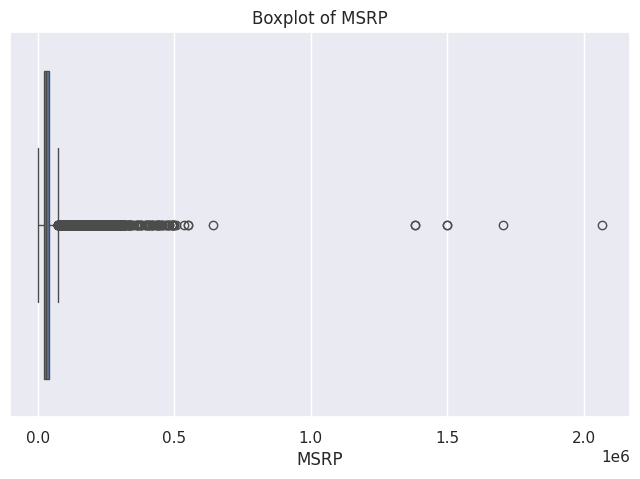

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['MSRP'])

plt.title("Boxplot of MSRP")
plt.show()

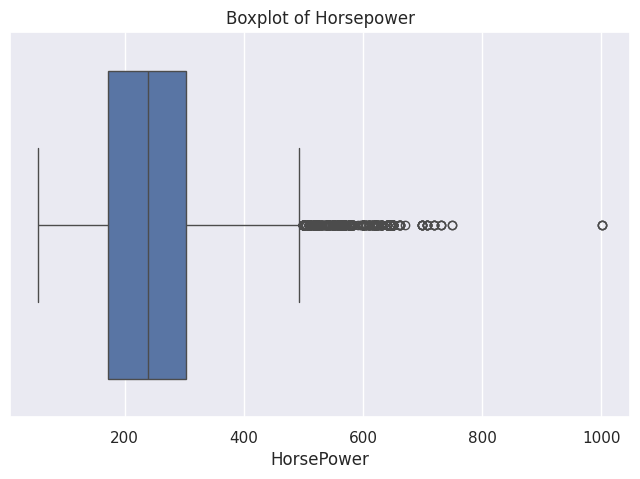

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['HorsePower'])

plt.title("Boxplot of Horsepower")
plt.show()

In [48]:
l = df.dtypes.loc[(df.dtypes == 'int64') | (df.dtypes == 'float64')]
l.index.tolist()

['Year', 'HorsePower', 'Cylinders', 'Highway_MPG', 'City_MPG', 'MSRP']

In [49]:
l = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(l)

['Year', 'HorsePower', 'Cylinders', 'Highway_MPG', 'City_MPG', 'MSRP']


In [50]:
# Calculate Q1
Q1 = df['MSRP'].quantile(0.25)

# Calculate Q3
Q3 = df['MSRP'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate thresholds
Lower_Limit = Q1 - 1.5 * IQR
Upper_Limit = Q3 + 1.5 * IQR

# Remove outliers
df2 = df[
    (df['MSRP'] >= Lower_Limit) &
    (df['MSRP'] <= Upper_Limit)
]

In [51]:
print("Rows before:", df.shape)
print("Rows after:", df2.shape)

Rows before: (10827, 10)
Rows after: (9891, 10)


In [33]:
for col in df.columns:
    print("Column:", col)
    print(df[col].value_counts())


Column: Make
Make
Chevrolet        1123
Ford              881
Volkswagen        809
Toyota            746
Dodge             626
Nissan            558
GMC               515
Honda             449
Mazda             423
Cadillac          397
Mercedes-Benz     353
Suzuki            351
BMW               334
Infiniti          330
Audi              328
Hyundai           303
Volvo             281
Subaru            256
Acura             252
Kia               231
Mitsubishi        213
Lexus             202
Buick             196
Chrysler          187
Pontiac           186
Lincoln           164
Oldsmobile        150
Land Rover        143
Porsche           136
Saab              111
Aston Martin       93
Plymouth           82
Bentley            74
Ferrari            69
FIAT               62
Scion              60
Maserati           58
Lamborghini        52
Rolls-Royce        31
Lotus              29
Tesla              18
HUMMER             17
Maybach            16
Alfa Romeo          5
McLaren       

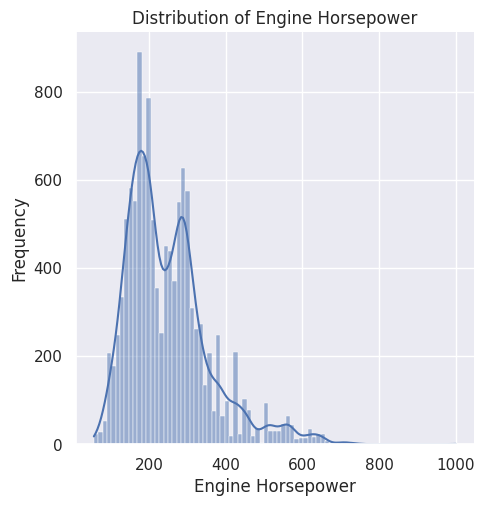

In [32]:
sns.displot(df['HorsePower'], kde=True)

plt.title("Distribution of Engine Horsepower")
plt.xlabel("Engine Horsepower")
plt.ylabel("Frequency")

plt.show()

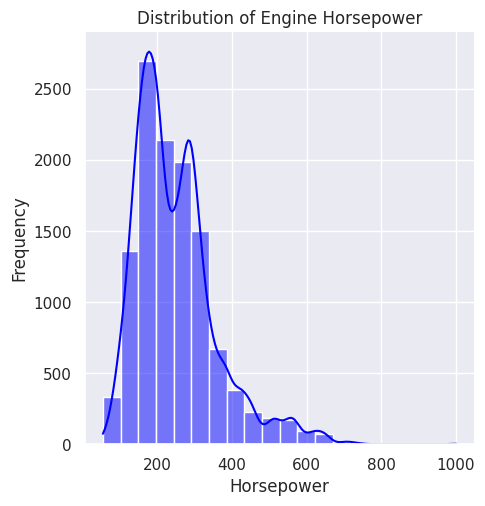

In [31]:
sns.displot(
    df['HorsePower'],
    kde=True,
    bins=20,
    color='blue'
)

plt.title("Distribution of Engine Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("Frequency")

plt.show()

In [30]:
c = 1
plt.figure(figsize=(15,10))

for i in l:
    plt.subplot(2,3,c)
    sns.histplot(df[i], kde=True)
    plt.title(i)
    c += 1

plt.tight_layout()
plt.show()

NameError: name 'l' is not defined

<Figure size 1500x1000 with 0 Axes>

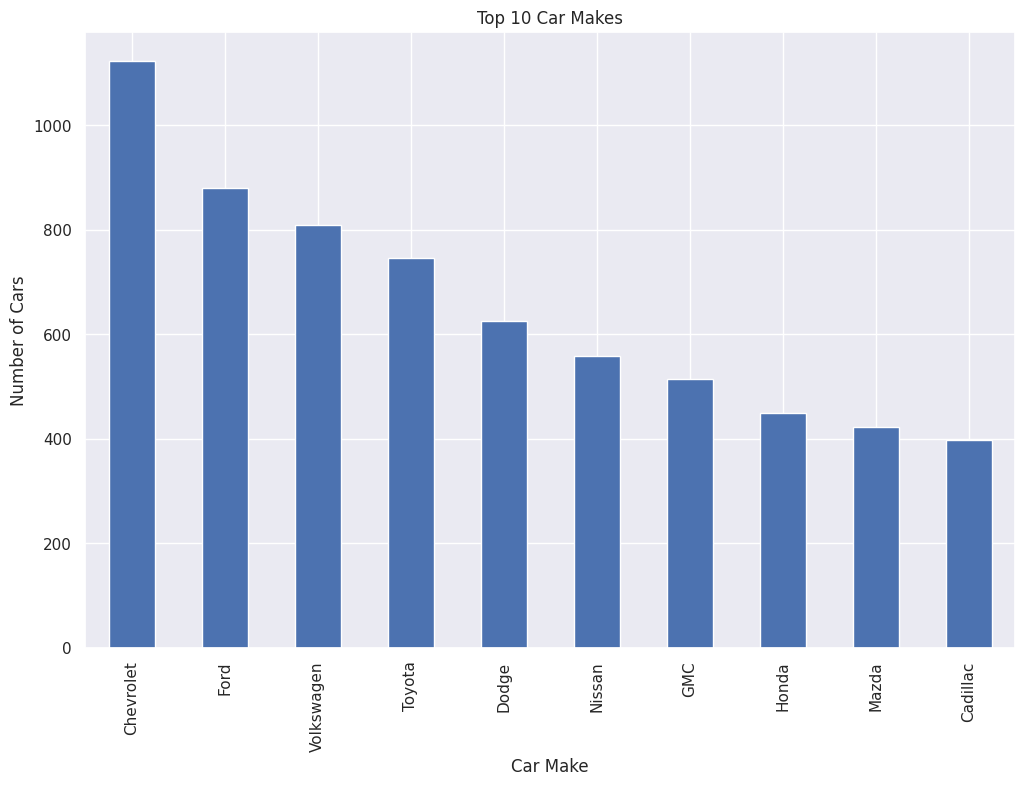

In [29]:
plt.figure(figsize=(12,8))
df['Make'].value_counts().nlargest(10).plot(kind='bar')

plt.title("Top 10 Car Makes")
plt.xlabel("Car Make")
plt.ylabel("Number of Cars")
plt.show()

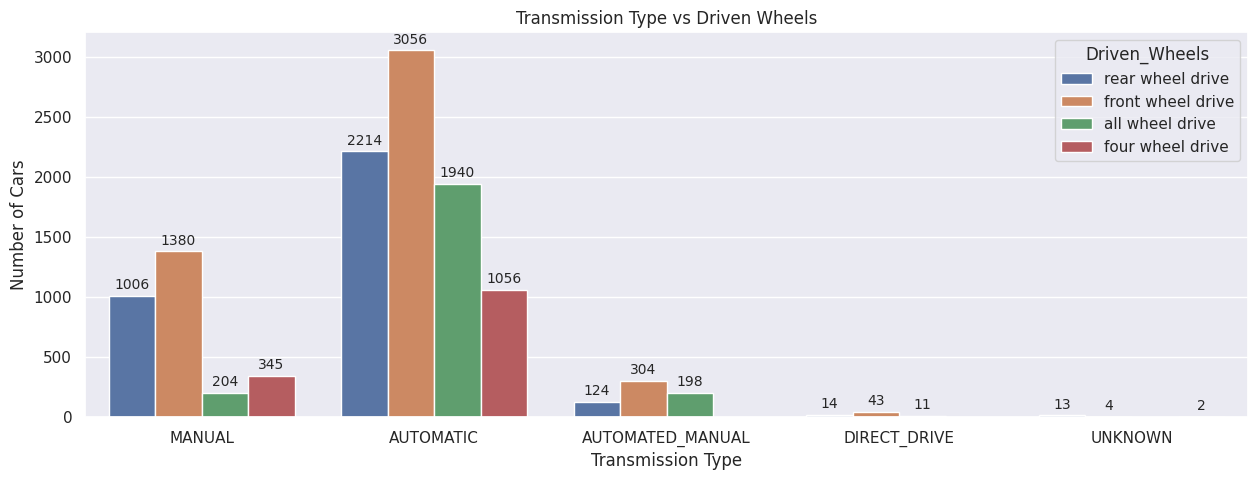

In [28]:
plt.figure(figsize=(15,5))
ax=sns.countplot(x='Transmission', hue='Driven_Wheels', data=df)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

plt.title("Transmission Type vs Driven Wheels")
plt.xlabel("Transmission Type")
plt.ylabel("Number of Cars")
plt.show()

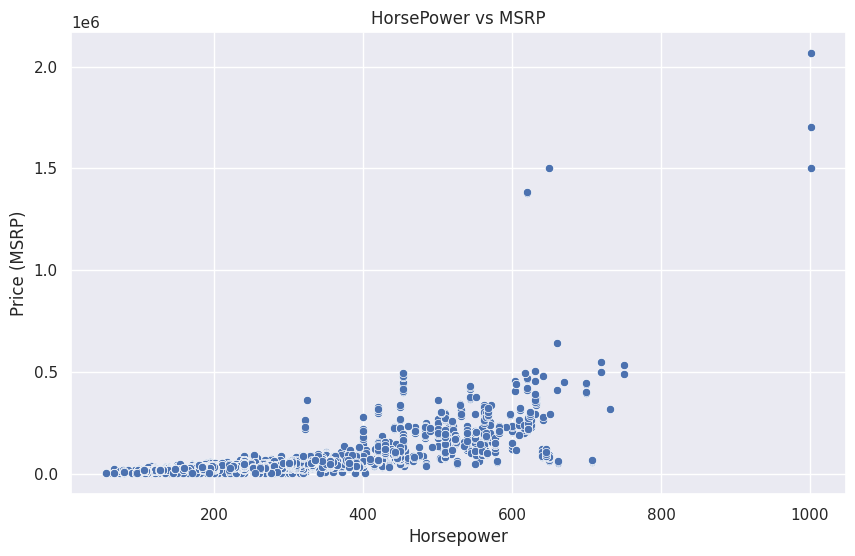

In [27]:
fig, ax = plt.subplots(figsize=(10,6))

sns.scatterplot(x='HorsePower', y='MSRP', data=df, ax=ax)

plt.title("HorsePower vs MSRP")
plt.xlabel("Horsepower")
plt.ylabel("Price (MSRP)")
plt.show()

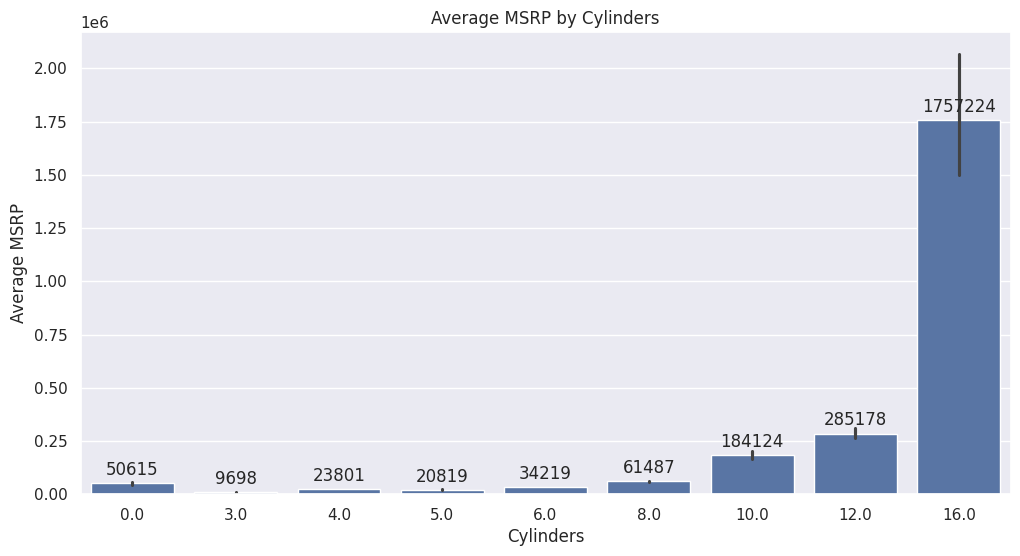

In [26]:
plt.figure(figsize=(12,6))

ax = sns.barplot(x='Cylinders', y='MSRP', data=df)

# Display mean values on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.title("Average MSRP by Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("Average MSRP")
plt.show()

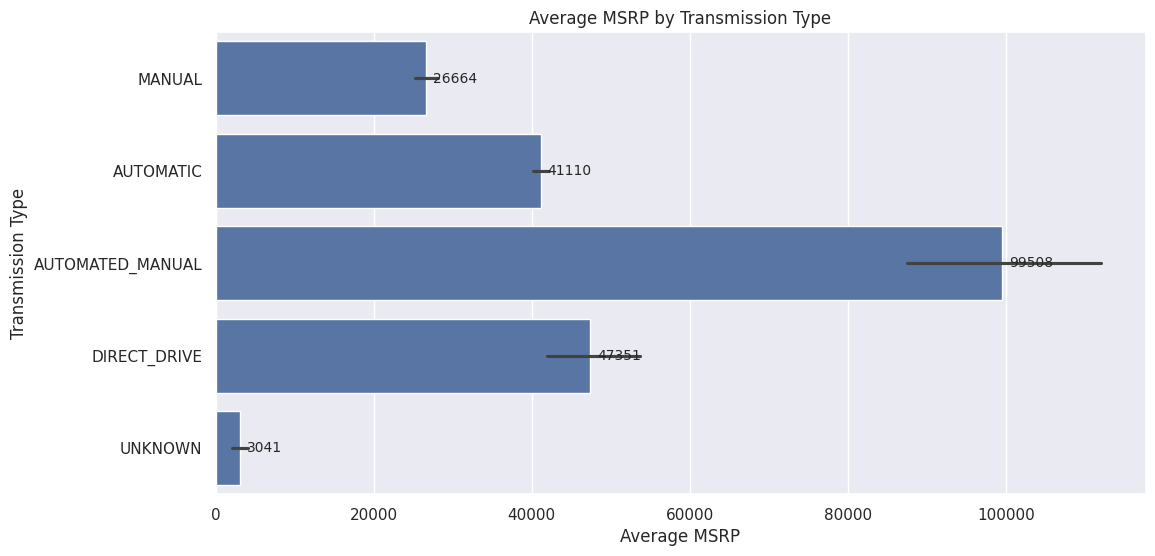

In [25]:
plt.figure(figsize=(12,6))
ax = sns.barplot(x='MSRP', y='Transmission', data=df)

# Data labels
for p in ax.patches:

  ax.annotate(
        f"{p.get_width():.0f}",
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left', va='center',
        fontsize=10, xytext=(5,0),
        textcoords='offset points'
    )

plt.title("Average MSRP by Transmission Type")
plt.xlabel("Average MSRP")
plt.ylabel("Transmission Type")
plt.show()

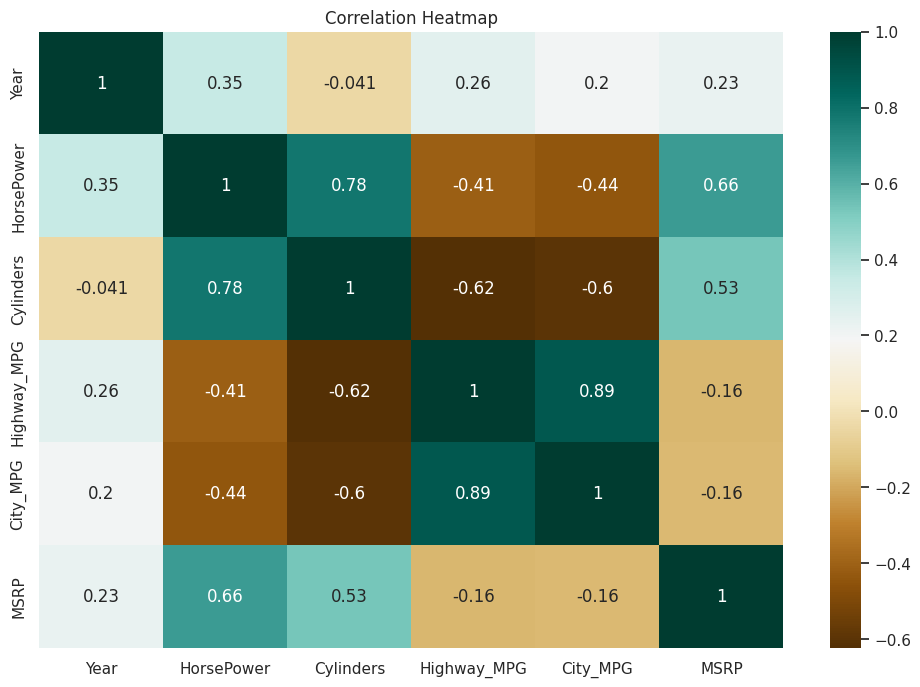

In [24]:
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='BrBG',annot=True)
plt.title("Correlation Heatmap")
plt.show()

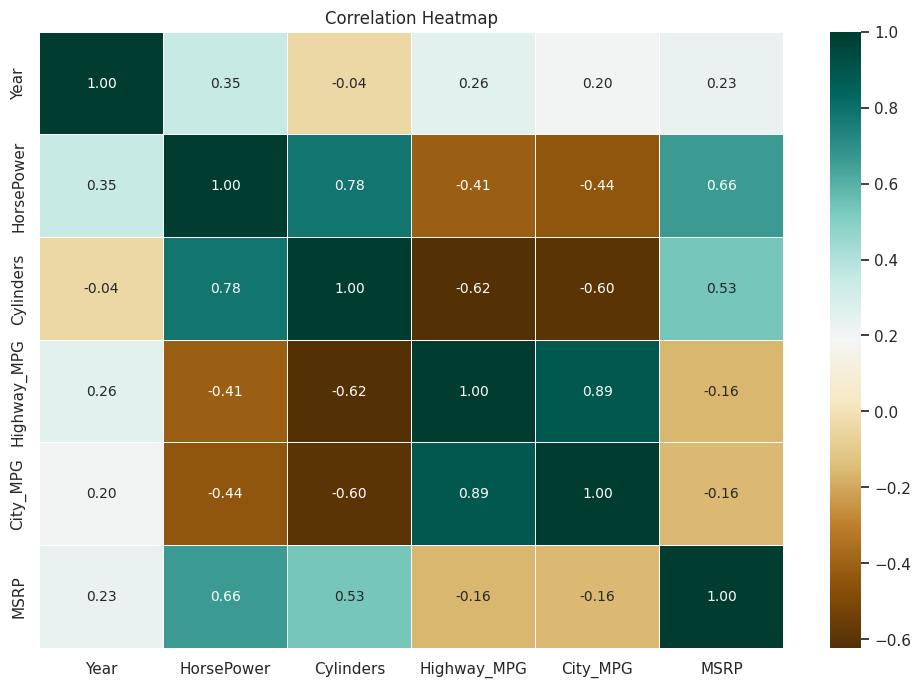

In [23]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))

sns.heatmap(
    corr, cmap='BrBG',
    annot=True, fmt=".2f",
    linewidths=0.5, annot_kws={"size":10}
)

plt.title("Correlation Heatmap")
plt.show()

In [22]:
df.head(5)

,Make,Model,Year,HorsePower,Cylinders,Transmission,Driven_Wheels,Highway_MPG,City_MPG,MSRP
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500
